MATPLOTLIB IS A VISUALIZATION LIBRARY ON PYTHON AND IT WORKS PERFECTLY TOGETHER WITH PYPLOT

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
chart = pd.read_excel("products summary.xlsx","sales details")
chart

,SA. RAP ID,ZONE,SALES RAP,DATE,MONTH,PRODUCT,BOXES,UNIT PRICE,TOTAL
0,SR001,SOUTH,PETER,2021-01-01,January,Orange,18,25,450
1,SR002,SOUTH,BISOLA,2021-01-01,January,Cherries,17,78,1326
2,SR003,SOUTH,VICTORIA,2021-01-01,January,Banana,92,18,1656
3,SR004,EAST,DANIEL,2021-01-01,January,Apple,88,45,3960
4,SR005,EAST,LOVETH,2021-01-01,January,Grapes,24,95,2280
...,...,...,...,...,...,...,...,...,...
442,SR008,WEST,GLORIA,2021-03-31,March,Cherries,12,78,936
443,SR009,WEST,ENIOLA,2021-03-31,March,Banana,91,18,1638
444,SR010,NORTH,HANNEY,2021-03-31,March,Apple,56,45,2520
445,SR011,NORTH,TEMITOPE,2021-03-31,March,Grapes,30,95,2850


In [2]:
#remove the extra space in the column headers
chart.columns = chart.columns.str.strip()

In [3]:
#renaming SA. RAP ID and SALES RAP columns
chart.rename(columns={"SA. RAP ID":"SALES REP ID","SALES RAP":"SALES REP"},inplace=True)
chart

,SALES REP ID,ZONE,SALES REP,DATE,MONTH,PRODUCT,BOXES,UNIT PRICE,TOTAL
0,SR001,SOUTH,PETER,2021-01-01,January,Orange,18,25,450
1,SR002,SOUTH,BISOLA,2021-01-01,January,Cherries,17,78,1326
2,SR003,SOUTH,VICTORIA,2021-01-01,January,Banana,92,18,1656
3,SR004,EAST,DANIEL,2021-01-01,January,Apple,88,45,3960
4,SR005,EAST,LOVETH,2021-01-01,January,Grapes,24,95,2280
...,...,...,...,...,...,...,...,...,...
442,SR008,WEST,GLORIA,2021-03-31,March,Cherries,12,78,936
443,SR009,WEST,ENIOLA,2021-03-31,March,Banana,91,18,1638
444,SR010,NORTH,HANNEY,2021-03-31,March,Apple,56,45,2520
445,SR011,NORTH,TEMITOPE,2021-03-31,March,Grapes,30,95,2850


In [4]:
#convert the zones and sales rep to proper case
chart["ZONE"] = chart["ZONE"].str.title()
chart["SALES REP"] = chart["SALES REP"].str.title()
chart

,SALES REP ID,ZONE,SALES REP,DATE,MONTH,PRODUCT,BOXES,UNIT PRICE,TOTAL
0,SR001,South,Peter,2021-01-01,January,Orange,18,25,450
1,SR002,South,Bisola,2021-01-01,January,Cherries,17,78,1326
2,SR003,South,Victoria,2021-01-01,January,Banana,92,18,1656
3,SR004,East,Daniel,2021-01-01,January,Apple,88,45,3960
4,SR005,East,Loveth,2021-01-01,January,Grapes,24,95,2280
...,...,...,...,...,...,...,...,...,...
442,SR008,West,Gloria,2021-03-31,March,Cherries,12,78,936
443,SR009,West,Eniola,2021-03-31,March,Banana,91,18,1638
444,SR010,North,Hanney,2021-03-31,March,Apple,56,45,2520
445,SR011,North,Temitope,2021-03-31,March,Grapes,30,95,2850


In [5]:
#checking for duplicates
chart.drop_duplicates()

,SALES REP ID,ZONE,SALES REP,DATE,MONTH,PRODUCT,BOXES,UNIT PRICE,TOTAL
0,SR001,South,Peter,2021-01-01,January,Orange,18,25,450
1,SR002,South,Bisola,2021-01-01,January,Cherries,17,78,1326
2,SR003,South,Victoria,2021-01-01,January,Banana,92,18,1656
3,SR004,East,Daniel,2021-01-01,January,Apple,88,45,3960
4,SR005,East,Loveth,2021-01-01,January,Grapes,24,95,2280
...,...,...,...,...,...,...,...,...,...
442,SR008,West,Gloria,2021-03-31,March,Cherries,12,78,936
443,SR009,West,Eniola,2021-03-31,March,Banana,91,18,1638
444,SR010,North,Hanney,2021-03-31,March,Apple,56,45,2520
445,SR011,North,Temitope,2021-03-31,March,Grapes,30,95,2850


In [12]:
chart["DATE"].dt.to_period("y")

0      2021
1      2021
2      2021
3      2021
4      2021
       ... 
442    2021
443    2021
444    2021
445    2021
446    2021
Name: DATE, Length: 447, dtype: period[A-DEC]

In [13]:
chart["YEAR"] = chart["DATE"].dt.to_period("y")
chart

,SALES REP ID,ZONE,SALES REP,DATE,MONTH,PRODUCT,BOXES,UNIT PRICE,TOTAL,YEAR
0,SR001,South,Peter,2021-01-01,January,Orange,18,25,450,2021
1,SR002,South,Bisola,2021-01-01,January,Cherries,17,78,1326,2021
2,SR003,South,Victoria,2021-01-01,January,Banana,92,18,1656,2021
3,SR004,East,Daniel,2021-01-01,January,Apple,88,45,3960,2021
4,SR005,East,Loveth,2021-01-01,January,Grapes,24,95,2280,2021
...,...,...,...,...,...,...,...,...,...,...
442,SR008,West,Gloria,2021-03-31,March,Cherries,12,78,936,2021
443,SR009,West,Eniola,2021-03-31,March,Banana,91,18,1638,2021
444,SR010,North,Hanney,2021-03-31,March,Apple,56,45,2520,2021
445,SR011,North,Temitope,2021-03-31,March,Grapes,30,95,2850,2021


In [14]:
#get the total sales by zones
a = chart.groupby(["ZONE"]).sum(numeric_only=True)["TOTAL"].reset_index()
a

,ZONE,TOTAL
0,East,251373
1,North,245417
2,South,206889
3,West,261353


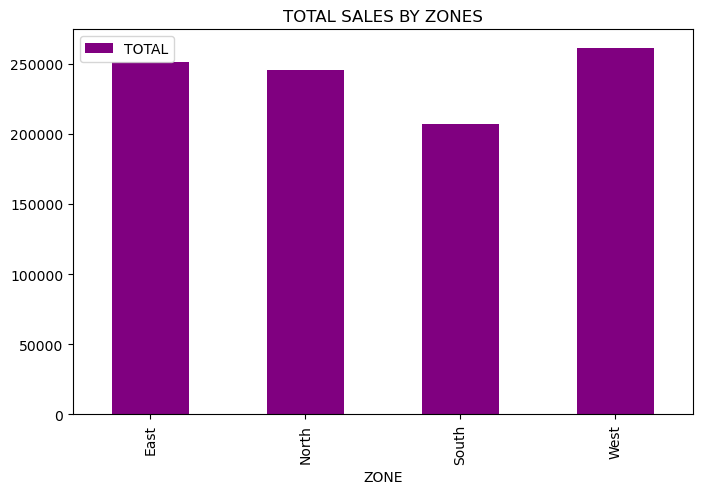

In [15]:
a.plot(kind="bar",x="ZONE",y="TOTAL",color="purple",figsize=[8,5],
       title = "TOTAL SALES BY ZONES")
plt.show()

In [16]:
#get the total boxes by products
b = chart.groupby(["PRODUCT"]).sum(numeric_only=True)["BOXES"].reset_index()
b

,PRODUCT,BOXES
0,Apple,3236
1,Banana,3341
2,Cherries,2960
3,Grapes,3041
4,Mangoes,3357
5,Orange,3324
6,Watermelon,3242


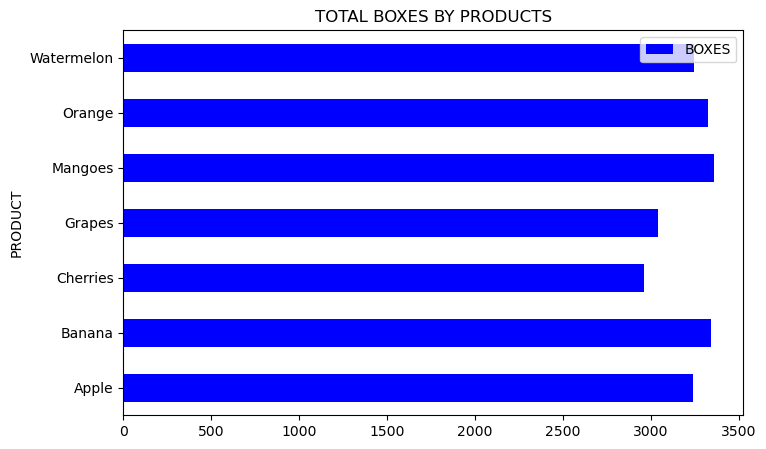

In [17]:
b.plot(kind="barh",x="PRODUCT",y="BOXES",color="blue",figsize=[8,5],
       title = "TOTAL BOXES BY PRODUCTS")
plt.show()

In [18]:
#get the total number of boxes by unit price and products
c = chart.groupby(["PRODUCT"]).sum(numeric_only=True)[["UNIT PRICE","BOXES"]].reset_index()
c

,PRODUCT,UNIT PRICE,BOXES
0,Apple,2880,3236
1,Banana,1152,3341
2,Cherries,4992,2960
3,Grapes,6080,3041
4,Mangoes,2240,3357
5,Orange,1600,3324
6,Watermelon,756,3242


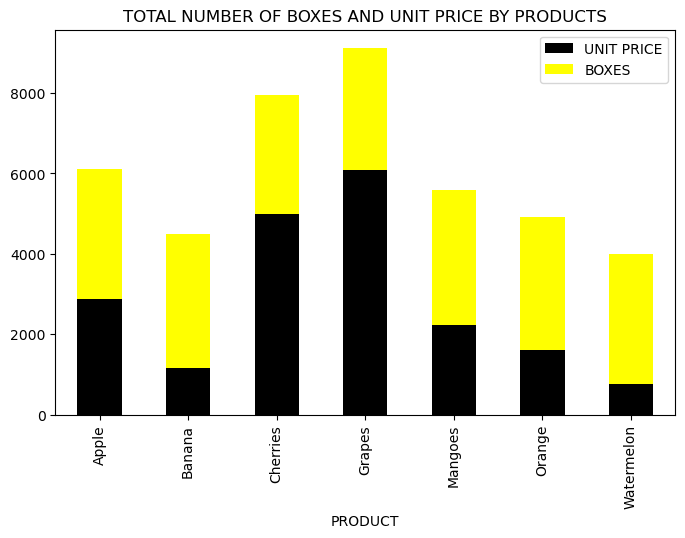

In [19]:
c.plot(kind="bar",x="PRODUCT",y=["UNIT PRICE","BOXES"],stacked=True,color=["black","yellow"],figsize=[8,5],
       title = "TOTAL NUMBER OF BOXES AND UNIT PRICE BY PRODUCTS")
plt.show()

In [20]:
#get the total sales by month
d = chart.groupby(["MONTH"]).sum(numeric_only=True)["TOTAL"].reset_index()
d

,MONTH,TOTAL
0,February,283964
1,January,366786
2,March,314282


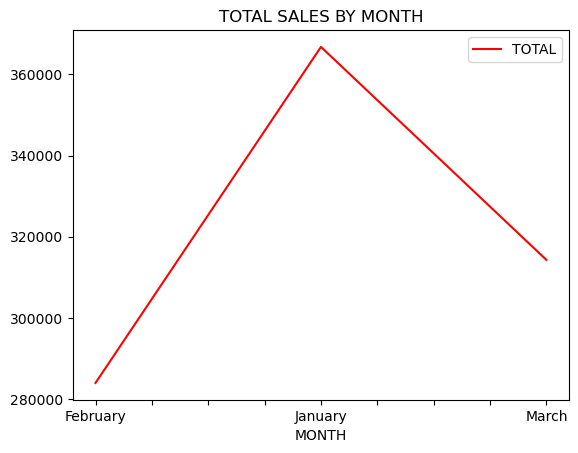

In [32]:
d.plot(kind="line",x="MONTH",y="TOTAL",color="red",
       title = "TOTAL SALES BY MONTH")
plt.show()

In [21]:
#get the total sales by sales rep
e = chart.groupby(["SALES REP"]).sum(numeric_only=True)["TOTAL"].reset_index()
e

,SALES REP,TOTAL
0,Bisola,62413
1,Daniel,87335
2,Eniola,78613
3,Gloria,96831
4,Hanney,97876
5,Loveth,78226
6,Mosun,85909
7,Peter,81944
8,Temitope,169751
9,Victoria,62532


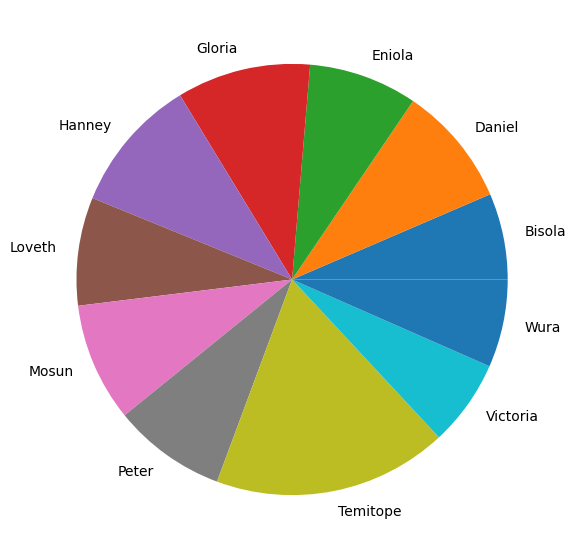

In [22]:
plt.figure(figsize=(10,7))
plt.pie(e["TOTAL"], labels=e["SALES REP"])
plt.show()

In [23]:
#get the total unit price by product
f = chart.groupby(["PRODUCT"]).sum(numeric_only=True)["UNIT PRICE"].reset_index()
f

,PRODUCT,UNIT PRICE
0,Apple,2880
1,Banana,1152
2,Cherries,4992
3,Grapes,6080
4,Mangoes,2240
5,Orange,1600
6,Watermelon,756


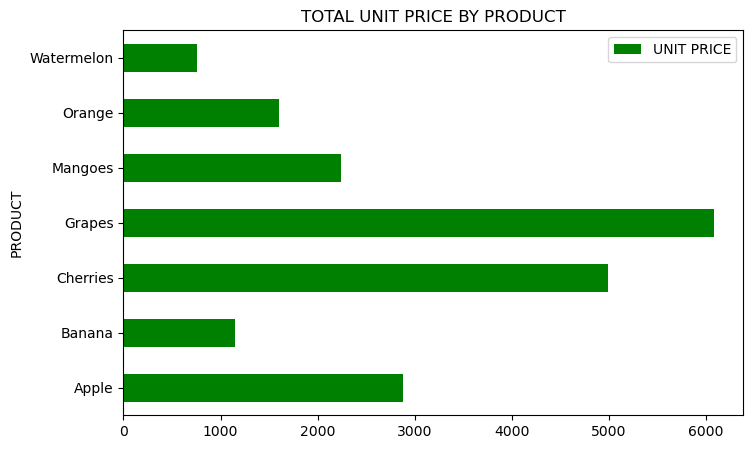

In [24]:
f.plot(kind="barh",x="PRODUCT",y="UNIT PRICE",color="green",figsize=[8,5],
       title = "TOTAL UNIT PRICE BY PRODUCT")
plt.show()

In [25]:
#get the total sales by product
g = chart.groupby(["PRODUCT"]).sum(numeric_only=True)["TOTAL"].reset_index()
g

,PRODUCT,TOTAL
0,Apple,145620
1,Banana,60138
2,Cherries,230880
3,Grapes,288895
4,Mangoes,117495
5,Orange,83100
6,Watermelon,38904


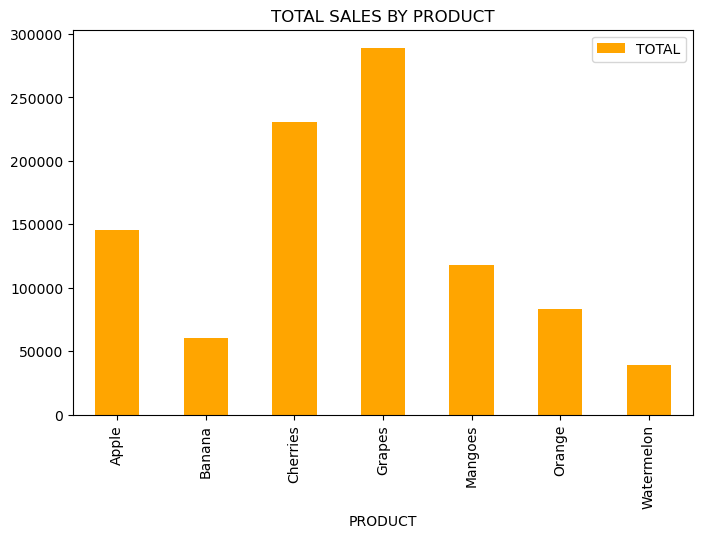

In [26]:
g.plot(kind="bar",x="PRODUCT",y="TOTAL",color="orange",figsize=[8,5],
       title = "TOTAL SALES BY PRODUCT")
plt.show()

In [27]:
#get the total sales by unit price and products
h = chart.groupby(["PRODUCT"]).sum(numeric_only=True)[["UNIT PRICE","TOTAL"]].reset_index()
h

,PRODUCT,UNIT PRICE,TOTAL
0,Apple,2880,145620
1,Banana,1152,60138
2,Cherries,4992,230880
3,Grapes,6080,288895
4,Mangoes,2240,117495
5,Orange,1600,83100
6,Watermelon,756,38904


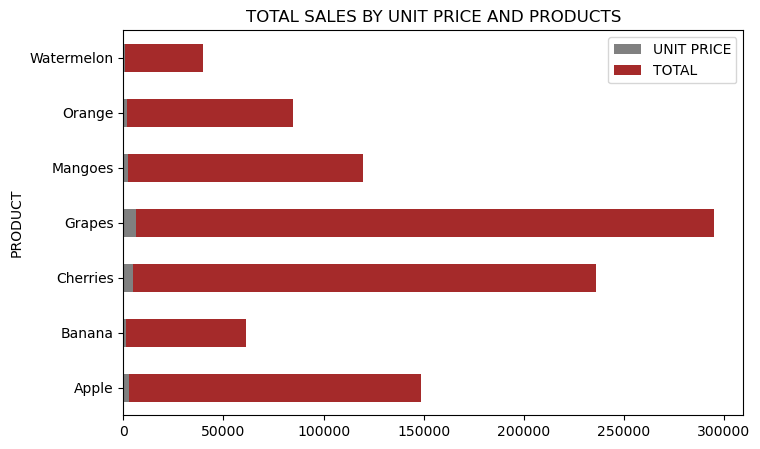

In [28]:
h.plot(kind="barh",x="PRODUCT",y=["UNIT PRICE","TOTAL"],stacked=True,color=["grey","brown"],figsize=[8,5],
       title = "TOTAL SALES BY UNIT PRICE AND PRODUCTS")
plt.show()

In [29]:
#get the total sales by boxes, unit price and products
i = chart.groupby(["PRODUCT"]).sum(numeric_only=True)[["BOXES","UNIT PRICE","TOTAL"]].reset_index()
i

,PRODUCT,BOXES,UNIT PRICE,TOTAL
0,Apple,3236,2880,145620
1,Banana,3341,1152,60138
2,Cherries,2960,4992,230880
3,Grapes,3041,6080,288895
4,Mangoes,3357,2240,117495
5,Orange,3324,1600,83100
6,Watermelon,3242,756,38904


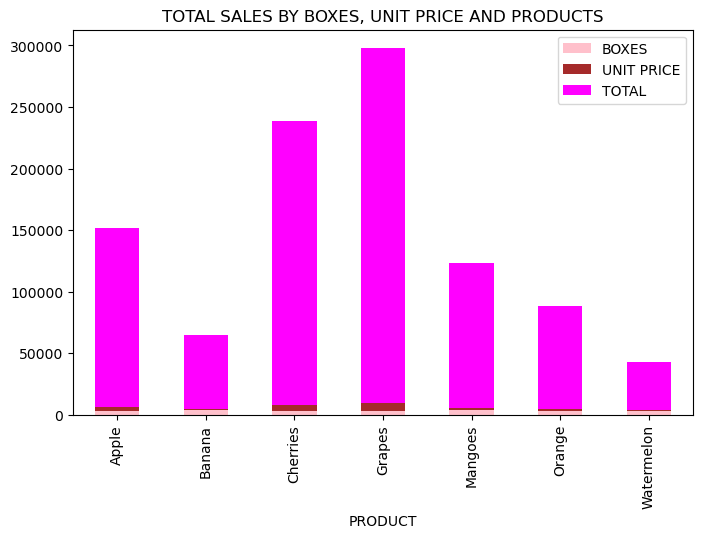

In [31]:
i.plot(kind="bar",x="PRODUCT",y=["BOXES","UNIT PRICE","TOTAL"],stacked=True,color=["pink","brown","magenta"],figsize=[8,5],
       title = "TOTAL SALES BY BOXES, UNIT PRICE AND PRODUCTS")
plt.show()